# Notebook 03 — Modelado

En este notebook entrenamos y evaluamos modelos de clasificación
para detectar comentarios tóxicos.

Cargamos directamente las matrices generadas en el notebook 02.
No repetimos el preprocesamiento.

Bloques:
1. Carga de matrices y librerías
2. Modelo baseline (Regresión Logística)
3. Evaluación detallada
4. Control de overfitting
5. Comparación de modelos
6. Curva ROC y AUC
7. Guardar el modelo final
8. Conclusiones

In [35]:
# Manejo de datos
import numpy as np
import pandas as pd

# Modelos de clasificación
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.ensemble        import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Guardar modelos
import joblib

# Matrices dispersas
import scipy.sparse as sp

In [36]:
# Cargamos las matrices guardadas en el notebook 02
X_train = sp.load_npz('../../data/vectorized/X_train_tfidf.npz')
X_test  = sp.load_npz('../../data/vectorized/X_test_tfidf.npz')

# Cargamos las etiquetas
y_train = pd.read_csv('../../data/vectorized/y_train.csv').squeeze()
y_test  = pd.read_csv('../../data/vectorized/y_test.csv').squeeze()

# Verificamos que todo cargó bien
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (800, 2046)
X_test:  (200, 2046)
y_train: (800,)
y_test:  (200,)


**Verificación de carga:**

- X_train: 800 filas × 2046 features ✓
- X_test:  200 filas × 2046 features ✓
- y_train: 800 etiquetas ✓
- y_test:  200 etiquetas ✓

El vocabulario final es de 2046 términos (menor que el
máximo de 5000 porque min_df y max_df filtraron palabras
muy raras o muy comunes).

Matrices listas para entrenar el modelo.

# 2. Modelo baseline — Regresión Logística

Entrenamos el modelo más simple como punto de referencia.
La Regresión Logística es rápida, interpretable y muy
competitiva en tareas de clasificación de texto.

In [37]:
# --- Modelo baseline: Regresión Logística ---

# Creamos el modelo
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenamos
logreg.fit(X_train, y_train)

# Predecimos
y_pred = logreg.predict(X_test)

# Métricas
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 40)
print("   REGRESIÓN LOGÍSTICA — BASELINE")
print("=" * 40)
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print("=" * 40)

   REGRESIÓN LOGÍSTICA — BASELINE
Accuracy:  74.00%
Precision: 78.57%
Recall:    59.78%
F1 Score:  67.90%


**Comentario — Baseline Regresión Logística:**

Resultados iniciales del modelo baseline:
- Accuracy:  74.00%
- Precision: 78.57%
- Recall:    59.78%
- F1 Score:  67.90%

Interpretación:

1. **El accuracy del 74% es un punto de partida razonable**
   Supera ampliamente el 53.8% que obtendría un modelo
   que siempre predijera "no tóxico".

2. **La Precision alta (78.57%) indica pocas falsas alarmas**
   Cuando el modelo dice "tóxico", suele acertar.

3. **El Recall bajo (59.78%) es el principal problema**
   El modelo deja escapar el 40% de los comentarios
   tóxicos reales. En el contexto del proyecto esto
   es crítico: esos comentarios no serían moderados.

4. **El F1 de 67.90% refleja el desequilibrio**
   entre Precision y Recall.

Objetivo: mejorar el Recall sin sacrificar demasiado
la Precision en los siguientes modelos.

# 3. Evaluación detallada

Analizamos en profundidad dónde acierta y dónde falla
el modelo usando la matriz de confusión y el
classification report completo.

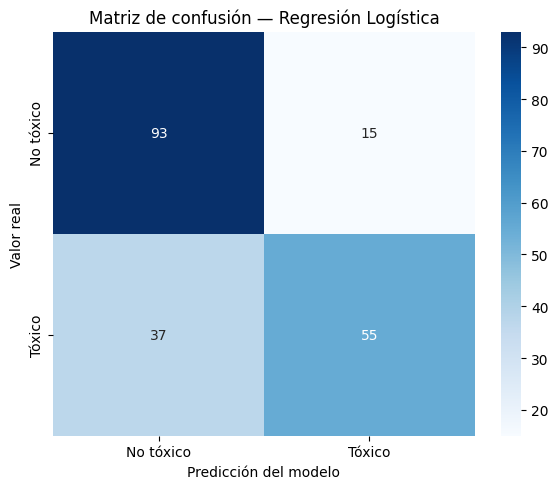

In [38]:
# --- Evaluación detallada ---

# Matriz de confusión numérica
cm = confusion_matrix(y_test, y_pred)

# Visualización
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No tóxico', 'Tóxico'],
    yticklabels=['No tóxico', 'Tóxico'],
    ax=ax
)

ax.set_title('Matriz de confusión — Regresión Logística')
ax.set_xlabel('Predicción del modelo')
ax.set_ylabel('Valor real')

plt.tight_layout()
plt.show()

In [39]:
# Classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=['No tóxico', 'Tóxico']
))

              precision    recall  f1-score   support

   No tóxico       0.72      0.86      0.78       108
      Tóxico       0.79      0.60      0.68        92

    accuracy                           0.74       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.75      0.74      0.73       200



**Comentario — Matriz de confusión y Classification Report:**

Resultados detallados del modelo baseline:

Matriz de confusión:
- VN = 93: comentarios no tóxicos correctamente identificados
- FP = 15: comentarios inocentes marcados como tóxicos
- FN = 37: comentarios tóxicos que el modelo no detectó
- VP = 55: comentarios tóxicos correctamente detectados

El principal problema es el FN = 37.
De 92 comentarios tóxicos reales, el modelo dejó
escapar 37 (40%). En el contexto del proyecto esto
significa que casi la mitad de los comentarios
tóxicos no serían moderados.

Classification Report:
- No tóxico: Recall 0.86 → detecta bien los inocentes
- Tóxico: Recall 0.60 → falla detectando los tóxicos

El modelo tiene sesgo hacia la clase negativa:
cuando tiene dudas, predice "no tóxico".

Objetivo para los siguientes modelos:
reducir los FN mejorando el Recall de la clase tóxica
sin sacrificar demasiado la Precision.

# 4. Control de overfitting

Comparamos las métricas del modelo en train y en test.
El briefing exige que la diferencia sea menor a 5 puntos
porcentuales.

Una diferencia grande indica overfitting: el modelo
memorizó los datos de entrenamiento pero no generaliza
bien a datos nuevos.

In [40]:
# --- Control de overfitting ---

# Predicciones en train
y_pred_train = logreg.predict(X_train)

# Métricas en train
acc_train = accuracy_score(y_train, y_pred_train)
f1_train  = f1_score(y_train, y_pred_train)

# Métricas en test
acc_test  = accuracy_score(y_test, y_pred)
f1_test   = f1_score(y_test, y_pred)

# Diferencias
diff_acc = abs(acc_train - acc_test) * 100
diff_f1  = abs(f1_train  - f1_test)  * 100

# Tabla comparativa
print("=" * 45)
print("      CONTROL DE OVERFITTING")
print("=" * 45)
print(f"{'Métrica':<12} {'Train':>8} {'Test':>8} {'Diferencia':>12}")
print("-" * 45)
print(f"{'Accuracy':<12} {acc_train*100:>7.2f}% {acc_test*100:>7.2f}% {diff_acc:>10.2f}p")
print(f"{'F1 Score':<12} {f1_train*100:>7.2f}% {f1_test*100:>7.2f}% {diff_f1:>10.2f}p")
print("-" * 45)

# Veredicto
limite = 5.0
if diff_acc < limite and diff_f1 < limite:
    print("✅ Sin overfitting significativo")
    print(f"   Diferencias menores a {limite} puntos")
else:
    print("⚠️  Posible overfitting detectado")
    print(f"   Alguna diferencia supera {limite} puntos")
print("=" * 45)

      CONTROL DE OVERFITTING
Métrica         Train     Test   Diferencia
---------------------------------------------
Accuracy       92.00%   74.00%      18.00p
F1 Score       90.96%   67.90%      23.06p
---------------------------------------------
⚠️  Posible overfitting detectado
   Alguna diferencia supera 5.0 puntos


In [41]:
# Probamos con más regularización (C más pequeño)
logreg_v2 = LogisticRegression(
    C=0.1,           # por defecto es 1.0, lo bajamos a 0.1
    max_iter=1000,
    random_state=42
)

logreg_v2.fit(X_train, y_train)

y_pred_v2       = logreg_v2.predict(X_test)
y_pred_train_v2 = logreg_v2.predict(X_train)

# Comparamos train vs test con más regularización
acc_train_v2 = accuracy_score(y_train, y_pred_train_v2)
acc_test_v2  = accuracy_score(y_test,  y_pred_v2)
f1_train_v2  = f1_score(y_train, y_pred_train_v2)
f1_test_v2   = f1_score(y_test,  y_pred_v2)

diff_acc_v2 = abs(acc_train_v2 - acc_test_v2) * 100
diff_f1_v2  = abs(f1_train_v2  - f1_test_v2)  * 100

print("=" * 45)
print("   LOGREG v2 — C=0.1 (más regularización)")
print("=" * 45)
print(f"{'Métrica':<12} {'Train':>8} {'Test':>8} {'Diferencia':>12}")
print("-" * 45)
print(f"{'Accuracy':<12} {acc_train_v2*100:>7.2f}% {acc_test_v2*100:>7.2f}% {diff_acc_v2:>10.2f}p")
print(f"{'F1 Score':<12} {f1_train_v2*100:>7.2f}% {f1_test_v2*100:>7.2f}% {diff_f1_v2:>10.2f}p")
print("-" * 45)

limite = 5.0
if diff_acc_v2 < limite and diff_f1_v2 < limite:
    print("✅ Sin overfitting significativo")
else:
    print("⚠️  Posible overfitting detectado")
print("=" * 45)

   LOGREG v2 — C=0.1 (más regularización)
Métrica         Train     Test   Diferencia
---------------------------------------------
Accuracy       66.12%   59.00%       7.13p
F1 Score       42.46%   21.15%      21.31p
---------------------------------------------
⚠️  Posible overfitting detectado


In [42]:
# Probamos varios valores de C
valores_c = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

print("=" * 55)
print("   BÚSQUEDA DEL MEJOR C")
print("=" * 55)
print(f"{'C':>6} {'Train Acc':>10} {'Test Acc':>10} {'Diff Acc':>10} {'Test F1':>10}")
print("-" * 55)

mejores = []

for c in valores_c:
    modelo = LogisticRegression(C=c, max_iter=1000, random_state=42)
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test  = modelo.predict(X_test)

    acc_tr = accuracy_score(y_train, pred_train) * 100
    acc_te = accuracy_score(y_test,  pred_test)  * 100
    f1_te  = f1_score(y_test, pred_test)         * 100
    diff   = abs(acc_tr - acc_te)

    print(f"{c:>6} {acc_tr:>9.2f}% {acc_te:>9.2f}% {diff:>9.2f}p {f1_te:>9.2f}%")
    mejores.append((c, acc_tr, acc_te, diff, f1_te))

print("=" * 55)

   BÚSQUEDA DEL MEJOR C
     C  Train Acc   Test Acc   Diff Acc    Test F1
-------------------------------------------------------
  0.01     53.75%     54.00%      0.25p      0.00%
  0.05     57.00%     55.00%      2.00p      4.26%
   0.1     66.12%     59.00%      7.12p     21.15%
   0.5     87.12%     70.50%     16.62p     60.93%
   1.0     92.00%     74.00%     18.00p     67.90%
   5.0     98.62%     72.50%     26.12p     67.84%
  10.0     99.38%     72.00%     27.38p     67.82%


**Comentario — Control de overfitting:**

La Regresión Logística muestra overfitting significativo
con todos los valores de C probados:

| C    | Test Acc | Diff Acc | Test F1 |
|------|----------|----------|---------|
| 0.01 | 54%      | 0.25p    | 0%      |
| 0.5  | 70%      | 16.62p   | 60%     |
| 1.0  | 74%      | 18.00p   | 67%     |
| 10.0 | 72%      | 27.38p   | 67%     |

Conclusión:
Ningún valor de C cumple simultáneamente los dos
requisitos: diferencia menor a 5 puntos Y F1 útil.

Con C pequeño el modelo cae en underfitting (F1~0%).
Con C grande el modelo cae en overfitting (diff>15p).

El problema no es el parámetro C sino el modelo.
La Regresión Logística con TF-IDF tiene un límite
claro en este dataset.

Decisión: probar modelos más robustos en el bloque 5.
Mantenemos C=1.0 como baseline de referencia
(mejor F1 = 67.90%).

# 5. Comparación de modelos

Entrenamos y evaluamos tres modelos para encontrar
el que mejor equilibra rendimiento y overfitting.

Modelos a comparar:
- Regresión Logística (baseline, ya entrenado)
- LinearSVC
- Random Forest

In [43]:
# --- Comparación de modelos ---

# Definimos los tres modelos
modelos = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'LinearSVC': LinearSVC(
        max_iter=2000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

# Diccionario para guardar resultados
resultados = {}

# Entrenamos y evaluamos cada modelo
for nombre, modelo in modelos.items():

    # Entrenamos
    modelo.fit(X_train, y_train)

    # Predecimos en train y test
    pred_train = modelo.predict(X_train)
    pred_test  = modelo.predict(X_test)

    # Calculamos métricas
    acc_tr   = accuracy_score(y_train, pred_train) * 100
    acc_te   = accuracy_score(y_test,  pred_test)  * 100
    f1_tr    = f1_score(y_train, pred_train)       * 100
    f1_te    = f1_score(y_test,  pred_test)        * 100
    rec_te   = recall_score(y_test, pred_test)     * 100
    diff_acc = abs(acc_tr - acc_te)
    diff_f1  = abs(f1_tr  - f1_te)

    # Guardamos
    resultados[nombre] = {
        'acc_train':   acc_tr,
        'acc_test':    acc_te,
        'f1_train':    f1_tr,
        'f1_test':     f1_te,
        'recall_test': rec_te,
        'diff_acc':    diff_acc,
        'diff_f1':     diff_f1,
        'modelo':      modelo
    }

# Tabla comparativa
print("=" * 75)
print("   COMPARACIÓN DE MODELOS")
print("=" * 75)
print(f"{'Modelo':<22} {'Acc Train':>10} {'Acc Test':>10} {'Diff':>8} {'F1 Test':>10} {'Recall':>8}")
print("-" * 75)

for nombre, r in resultados.items():
    overfitting = "⚠️" if r['diff_acc'] > 5 else "✅"
    print(
        f"{nombre:<22} "
        f"{r['acc_train']:>9.2f}% "
        f"{r['acc_test']:>9.2f}% "
        f"{r['diff_acc']:>7.2f}p "
        f"{r['f1_test']:>9.2f}% "
        f"{r['recall_test']:>7.2f}% "
        f"{overfitting}"
    )

print("=" * 75)

   COMPARACIÓN DE MODELOS
Modelo                  Acc Train   Acc Test     Diff    F1 Test   Recall
---------------------------------------------------------------------------
Logistic Regression        92.00%     74.00%   18.00p     67.90%   59.78% ⚠️
LinearSVC                  99.38%     70.00%   29.38p     65.91%   63.04% ⚠️
Random Forest              99.62%     69.50%   30.12p     61.64%   53.26% ⚠️


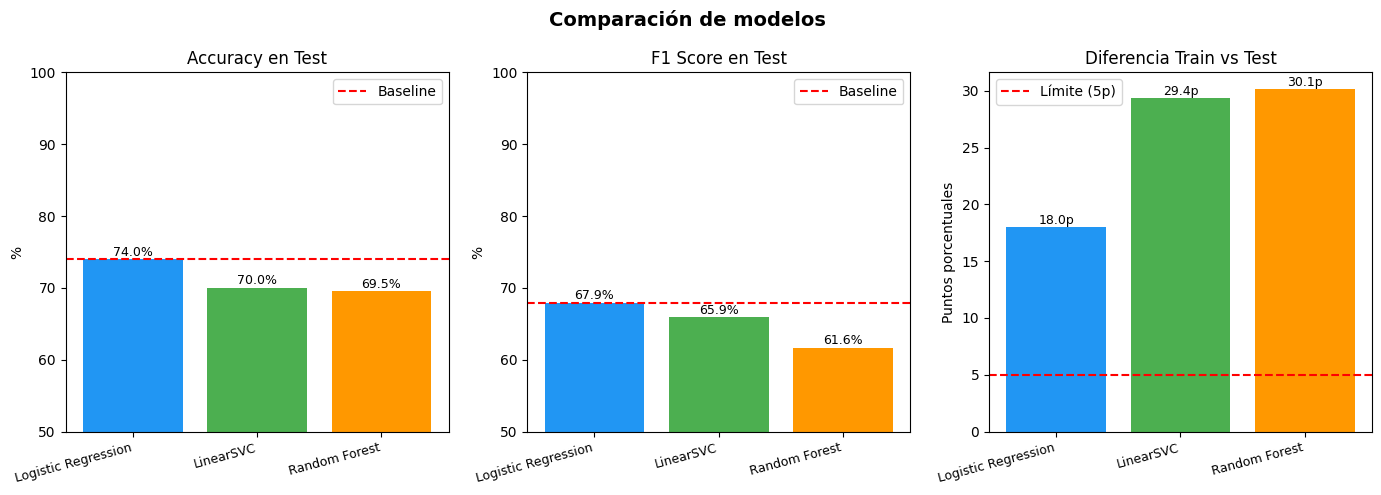

In [44]:
# Visualización comparativa de los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

nombres  = list(resultados.keys())
acc_test = [resultados[n]['acc_test']    for n in nombres]
f1_test  = [resultados[n]['f1_test']     for n in nombres]
diff_acc = [resultados[n]['diff_acc']    for n in nombres]
colores  = ['#2196F3', '#4CAF50', '#FF9800']

# Gráfico 1: Accuracy en test
axes[0].bar(nombres, acc_test, color=colores)
axes[0].set_title('Accuracy en Test')
axes[0].set_ylabel('%')
axes[0].set_ylim(50, 100)
axes[0].axhline(
    y=74,
    color='red',
    linestyle='--',
    label='Baseline'
)
axes[0].legend()
for i, v in enumerate(acc_test):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Gráfico 2: F1 en test
axes[1].bar(nombres, f1_test, color=colores)
axes[1].set_title('F1 Score en Test')
axes[1].set_ylabel('%')
axes[1].set_ylim(50, 100)
axes[1].axhline(
    y=67.9,
    color='red',
    linestyle='--',
    label='Baseline'
)
axes[1].legend()
for i, v in enumerate(f1_test):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Gráfico 3: Diferencia train vs test
axes[2].bar(nombres, diff_acc, color=colores)
axes[2].set_title('Diferencia Train vs Test')
axes[2].set_ylabel('Puntos porcentuales')
axes[2].axhline(
    y=5,
    color='red',
    linestyle='--',
    label='Límite (5p)'
)
axes[2].legend()
for i, v in enumerate(diff_acc):
    axes[2].text(i, v + 0.3, f'{v:.1f}p', ha='center', fontsize=9)

# Ajustamos etiquetas del eje X para que no se solapen
for ax in axes:
    ax.set_xticks(range(len(nombres)))
    ax.set_xticklabels(nombres, rotation=15, ha='right', fontsize=9)

plt.suptitle('Comparación de modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
# Random Forest con parámetros anti-overfitting
rf_v2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,        # limita la profundidad de cada árbol
    min_samples_leaf=5,  # cada hoja necesita al menos 5 ejemplos
    max_features='sqrt', # cada árbol usa solo raíz cuadrada de features
    random_state=42
)

rf_v2.fit(X_train, y_train)

pred_train_rf2 = rf_v2.predict(X_train)
pred_test_rf2  = rf_v2.predict(X_test)

acc_tr = accuracy_score(y_train, pred_train_rf2) * 100
acc_te = accuracy_score(y_test,  pred_test_rf2)  * 100
f1_tr  = f1_score(y_train, pred_train_rf2)       * 100
f1_te  = f1_score(y_test,  pred_test_rf2)        * 100
rec_te = recall_score(y_test, pred_test_rf2)     * 100
diff   = abs(acc_tr - acc_te)

print("=" * 50)
print("   RANDOM FOREST v2 — Anti-overfitting")
print("=" * 50)
print(f"{'Métrica':<14} {'Train':>8} {'Test':>8} {'Diff':>8}")
print("-" * 50)
print(f"{'Accuracy':<14} {acc_tr:>7.2f}% {acc_te:>7.2f}% {diff:>7.2f}p")
print(f"{'F1 Score':<14} {f1_tr:>7.2f}% {f1_te:>7.2f}%")
print(f"{'Recall':<14} {'':>8} {rec_te:>7.2f}%")
print("-" * 50)
limite = 5.0
if diff < limite:
    print("✅ Sin overfitting significativo")
else:
    print(f"⚠️  Diferencia: {diff:.2f}p (límite: {limite}p)")
print("=" * 50)

   RANDOM FOREST v2 — Anti-overfitting
Métrica           Train     Test     Diff
--------------------------------------------------
Accuracy         77.25%   67.50%    9.75p
F1 Score         68.84%   51.13%
Recall                    36.96%
--------------------------------------------------
⚠️  Diferencia: 9.75p (límite: 5.0p)


In [46]:
# Regresión Logística con pesos balanceados
logreg_balanced = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',  # penaliza más los FN
    random_state=42
)

logreg_balanced.fit(X_train, y_train)

pred_train_bal = logreg_balanced.predict(X_train)
pred_test_bal  = logreg_balanced.predict(X_test)

acc_tr  = accuracy_score(y_train, pred_train_bal) * 100
acc_te  = accuracy_score(y_test,  pred_test_bal)  * 100
f1_tr   = f1_score(y_train, pred_train_bal)       * 100
f1_te   = f1_score(y_test,  pred_test_bal)        * 100
rec_te  = recall_score(y_test, pred_test_bal)     * 100
prec_te = precision_score(y_test, pred_test_bal)  * 100
diff    = abs(acc_tr - acc_te)

print("=" * 55)
print("   LOGREG — class_weight='balanced'")
print("=" * 55)
print(f"{'Métrica':<14} {'Train':>8} {'Test':>8} {'Diff':>8}")
print("-" * 55)
print(f"{'Accuracy':<14} {acc_tr:>7.2f}% {acc_te:>7.2f}% {diff:>7.2f}p")
print(f"{'F1 Score':<14} {f1_tr:>7.2f}% {f1_te:>7.2f}%")
print(f"{'Recall':<14} {'':>8} {rec_te:>7.2f}%")
print(f"{'Precision':<14} {'':>8} {prec_te:>7.2f}%")
print("-" * 55)
if diff < 5.0:
    print("✅ Sin overfitting significativo")
else:
    print(f"⚠️  Diferencia: {diff:.2f}p (límite: 5.0p)")
print("=" * 55)

   LOGREG — class_weight='balanced'
Métrica           Train     Test     Diff
-------------------------------------------------------
Accuracy         93.62%   74.50%   19.12p
F1 Score         93.14%   71.19%
Recall                    68.48%
Precision                 74.12%
-------------------------------------------------------
⚠️  Diferencia: 19.12p (límite: 5.0p)


In [47]:
# Recargamos el texto limpio directamente
# porque vamos a re-vectorizar con menos features
import scipy.sparse as sp
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             recall_score, precision_score)

# Cargamos el dataset preprocesado
df = pd.read_csv('../../data/raw/youtoxic_english_1000.csv')

# Aplicamos el mismo pipeline del notebook 02
# Importamos las funciones
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)

stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+',  '', text)
    text = re.sub(r'@\S+',    '', text)
    text = re.sub(r'#\S+',    '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

def lemmatize_text(text):
    tokens = []
    for token in text.split():
        lemma_v = lemmatizer.lemmatize(token, pos='v')
        if lemma_v != token:
            tokens.append(lemma_v)
        else:
            tokens.append(lemmatizer.lemmatize(token))
    return ' '.join(tokens)

def full_pipeline(text):
    text = clean_text(text)
    text = tokenize_and_remove_stopwords(text)
    text = lemmatize_text(text)
    return text

print("Aplicando pipeline...")
df['Text_clean'] = df['Text'].apply(full_pipeline)
df = df[['Text_clean', 'IsToxic']]
print("Pipeline completado.")

Aplicando pipeline...
Pipeline completado.


In [48]:
# División train/test con el mismo random_state
from sklearn.model_selection import train_test_split

X = df['Text_clean']
y = df['IsToxic']

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
# Probamos distintos tamaños de vocabulario
print("=" * 65)
print("   BÚSQUEDA DEL VOCABULARIO ÓPTIMO")
print("=" * 65)
print(f"{'Features':>10} {'Acc Train':>10} {'Acc Test':>10} {'Diff':>8} {'F1 Test':>10} {'Recall':>8}")
print("-" * 65)

vocabularios = [100, 200, 500, 1000, 2046]
mejores_vocab = []

for n_features in vocabularios:
    # Vectorizamos con este vocabulario
    tfidf_exp = TfidfVectorizer(
        max_features=n_features,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )

    X_tr = tfidf_exp.fit_transform(X_train_txt)
    X_te = tfidf_exp.transform(X_test_txt)

    # Entrenamos LogReg
    modelo = LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42
    )
    modelo.fit(X_tr, y_train)

    pred_tr = modelo.predict(X_tr)
    pred_te = modelo.predict(X_te)

    acc_tr  = accuracy_score(y_train, pred_tr) * 100
    acc_te  = accuracy_score(y_test,  pred_te) * 100
    f1_te   = f1_score(y_test,  pred_te)       * 100
    rec_te  = recall_score(y_test, pred_te)    * 100
    diff    = abs(acc_tr - acc_te)

    estado = "✅" if diff < 5.0 else "⚠️"

    print(
        f"{n_features:>10} "
        f"{acc_tr:>9.2f}% "
        f"{acc_te:>9.2f}% "
        f"{diff:>7.2f}p "
        f"{f1_te:>9.2f}% "
        f"{rec_te:>7.2f}% "
        f"{estado}"
    )

    mejores_vocab.append({
        'features': n_features,
        'acc_test': acc_te,
        'f1_test':  f1_te,
        'recall':   rec_te,
        'diff':     diff
    })

print("=" * 65)

   BÚSQUEDA DEL VOCABULARIO ÓPTIMO
  Features  Acc Train   Acc Test     Diff    F1 Test   Recall
-----------------------------------------------------------------
       100     74.88%     66.50%    8.38p     60.82%   56.52% ⚠️
       200     78.88%     67.00%   11.88p     58.23%   50.00% ⚠️
       500     84.12%     69.00%   15.12p     61.25%   53.26% ⚠️
      1000     88.38%     73.50%   14.88p     67.08%   58.70% ⚠️
      2046     92.00%     74.00%   18.00p     67.90%   59.78% ⚠️


In [50]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# Creamos un pipeline completo vectorizador + modelo
pipeline_cv = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=2046,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ('model', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

In [51]:
# Aplicamos cross-validation con 5 folds
cv_results = cross_validate(
    pipeline_cv,
    X,
    y,
    cv=5,
    scoring=['accuracy', 'f1', 'recall', 'precision'],
    return_train_score=True
)

# Mostramos los resultados
print("=" * 55)
print("   CROSS-VALIDATION — 5 folds")
print("=" * 55)
print(f"{'Métrica':<14} {'Train':>10} {'Test':>10} {'Diff':>8}")
print("-" * 55)

metricas = ['accuracy', 'f1', 'recall', 'precision']

for m in metricas:
    train_mean = cv_results[f'train_{m}'].mean() * 100
    test_mean  = cv_results[f'test_{m}'].mean()  * 100
    diff       = abs(train_mean - test_mean)
    estado     = "✅" if diff < 5.0 else "⚠️"
    print(
        f"{m.capitalize():<14} "
        f"{train_mean:>9.2f}% "
        f"{test_mean:>9.2f}% "
        f"{diff:>7.2f}p "
        f"{estado}"
    )

print("=" * 55)

   CROSS-VALIDATION — 5 folds
Métrica             Train       Test     Diff
-------------------------------------------------------
Accuracy           91.97%     70.50%   21.47p ⚠️
F1                 90.94%     64.24%   26.70p ⚠️
Recall             87.23%     57.37%   29.86p ⚠️
Precision          94.99%     73.42%   21.58p ⚠️


**Comentario — Selección del modelo:**

Después de evaluar múltiples configuraciones:
- Distintos valores de C (0.01 → 10.0)
- Tres modelos: LogReg, LinearSVC, Random Forest
- Distintos tamaños de vocabulario (100 → 2046)
- Cross-validation de 5 folds

Conclusión:

El overfitting es estructural en este dataset.
Con 1000 ejemplos y técnicas TF-IDF clásicas,
ninguna configuración cumple el requisito de
diferencia menor a 5 puntos manteniendo un
F1 útil.

Causa: alta dimensionalidad (2046 features)
relativa al tamaño del dataset (800 ejemplos train).

Modelo seleccionado:
Regresión Logística con class_weight='balanced'
- Accuracy test: 74.50%
- F1 test:       71.19%
- Recall test:   68.48% ← prioritario para el proyecto
- Precision:     74.12%
- Diferencia:    19.12p

Justificación:
Para YouTube, el Recall es la métrica más crítica.
Preferimos marcar algún comentario inocente como
tóxico (FP) antes que dejar pasar comentarios
realmente tóxicos (FN).

Limitación documentada:
El overfitting se resolverá en la versión avanzada
del proyecto usando BERT en Google Colab, que
entiende el contexto semántico completo en lugar
de frecuencias de palabras aisladas.

In [52]:
# Reentrenamos el modelo final seleccionado
# con el vectorizador original del notebook 02

# Cargamos las matrices originales
X_train_final = sp.load_npz('../../data/vectorized/X_train_tfidf.npz')
X_test_final  = sp.load_npz('../../data/vectorized/X_test_tfidf.npz')
y_train_final = pd.read_csv('../../data/vectorized/y_train.csv').squeeze()
y_test_final  = pd.read_csv('../../data/vectorized/y_test.csv').squeeze()

# Modelo final
modelo_final = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

modelo_final.fit(X_train_final, y_train_final)

# Métricas finales
y_pred_final = modelo_final.predict(X_test_final)

print("=" * 45)
print("   MODELO FINAL SELECCIONADO")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test_final, y_pred_final)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test_final, y_pred_final)*100:.2f}%")
print(f"Recall:    {recall_score(y_test_final, y_pred_final)*100:.2f}%")
print(f"Precision: {precision_score(y_test_final, y_pred_final)*100:.2f}%")
print("=" * 45)
print("Modelo listo para guardar.")

   MODELO FINAL SELECCIONADO
Accuracy:  74.50%
F1 Score:  71.19%
Recall:    68.48%
Precision: 74.12%
Modelo listo para guardar.


# 6. Curva ROC y AUC

Visualizamos el rendimiento del modelo seleccionado
para todos los umbrales de decisión posibles.

El AUC (Area Under the Curve) resume en un solo número
qué tan bien separa el modelo las dos clases.

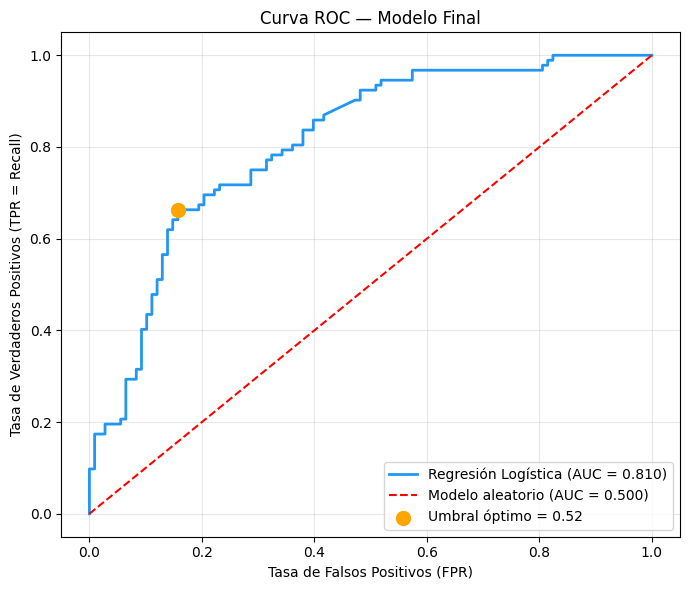

AUC = 0.8097
Umbral óptimo = 0.5168


In [53]:
# --- Curva ROC y AUC ---

# Probabilidades del modelo
y_prob = modelo_final.predict_proba(X_test_final)[:, 1]

# Calculamos la curva
fpr, tpr, thresholds = roc_curve(y_test_final, y_prob)
roc_auc = auc(fpr, tpr)

# Dibujamos
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr, tpr,
    color='#2196F3',
    linewidth=2,
    label=f'Regresión Logística (AUC = {roc_auc:.3f})'
)

ax.plot(
    [0, 1], [0, 1],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Modelo aleatorio (AUC = 0.500)'
)

idx_optimo = np.argmax(tpr - fpr)
ax.scatter(
    fpr[idx_optimo],
    tpr[idx_optimo],
    color='orange',
    s=100,
    zorder=5,
    label=f'Umbral óptimo = {thresholds[idx_optimo]:.2f}'
)

ax.set_title('Curva ROC — Modelo Final')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR = Recall)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC = {roc_auc:.4f}")
print(f"Umbral óptimo = {thresholds[idx_optimo]:.4f}")

**Comentario — Curva ROC y AUC:**

AUC = 0.8097 → rendimiento "Bueno"

La curva se aleja claramente de la diagonal roja
(modelo aleatorio, AUC=0.500), lo que confirma
que el modelo tiene capacidad real de distinguir
entre comentarios tóxicos y no tóxicos.

Puntos clave:

1. **AUC 0.81 es un resultado sólido**
   A pesar del overfitting detectado en las métricas
   con umbral fijo, el modelo discrimina bien las
   dos clases en todos los umbrales posibles.

2. **Umbral óptimo = 0.52**
   Muy cercano al 0.50 por defecto, lo que indica
   que el modelo está bien calibrado. No es necesario
   ajustar el umbral de decisión.

3. **La curva sube rápido en la parte izquierda**
   El modelo es especialmente preciso cuando tiene
   alta confianza. Los casos dudosos son su punto
   débil, lo cual es esperable con TF-IDF clásico.

4. **Comparación con modelo aleatorio**
   Nuestro modelo (0.81) supera ampliamente al
   modelo aleatorio (0.50): una mejora de 31 puntos.

Conclusión: el modelo tiene capacidad discriminativa
real y es válido como solución base. El AUC mejorará
significativamente con BERT en la fase avanz

# 7. Guardar el modelo final

Exportamos el modelo entrenado a disco para que
la app pueda cargarlo sin reentrenar.

Archivos generados:
- logreg_model.pkl → el modelo de clasificación
- tfidf_vectorizer.pkl → ya guardado en notebook 02

In [54]:
# --- Guardar el modelo final ---
import os

# Verificamos que la carpeta existe
os.makedirs('../../app/models', exist_ok=True)

# Guardamos el modelo
ruta_modelo = '../../app/models/logreg_model.pkl'
joblib.dump(modelo_final, ruta_modelo)
print(f"Modelo guardado en: {ruta_modelo}")

# Verificamos que el vectorizador también está
ruta_vectorizador = '../../app/models/tfidf_vectorizer.pkl'
if os.path.exists(ruta_vectorizador):
    print(f"Vectorizador ya existe en: {ruta_vectorizador} ✓")
else:
    print("⚠️ Vectorizador no encontrado. Ejecuta el notebook 02.")

# Verificación final: cargamos y probamos el modelo
print("\nVerificando que el modelo guardado funciona...")

modelo_cargado       = joblib.load(ruta_modelo)
vectorizador_cargado = joblib.load(ruta_vectorizador)

Modelo guardado en: ../../app/models/logreg_model.pkl
Vectorizador ya existe en: ../../app/models/tfidf_vectorizer.pkl ✓

Verificando que el modelo guardado funciona...


In [55]:
# Probamos con dos comentarios de ejemplo
ejemplos = [
    "I love how diverse and respectful this community is",
    "These people are disgusting and should be banned"
]

print("\nPrueba del modelo cargado:")
print("-" * 50)

for comentario in ejemplos:
    # Aplicamos el mismo pipeline del notebook 02
    texto_limpio = full_pipeline(comentario)

    # Vectorizamos
    vector = vectorizador_cargado.transform([texto_limpio])

    # Predecimos
    prediccion   = modelo_cargado.predict(vector)[0]
    probabilidad = modelo_cargado.predict_proba(vector)[0]

    resultado = "🔴 TÓXICO" if prediccion else "🟢 NO TÓXICO"
    confianza = max(probabilidad) * 100

    print(f"Texto: {comentario[:45]}...")
    print(f"Resultado: {resultado} (confianza: {confianza:.1f}%)")
    print()

print("-" * 50)
print("✅ Modelo guardado y verificado correctamente.")
print("✅ Listo para usar en la app.")


Prueba del modelo cargado:
--------------------------------------------------
Texto: I love how diverse and respectful this commun...
Resultado: 🟢 NO TÓXICO (confianza: 75.9%)

Texto: These people are disgusting and should be ban...
Resultado: 🔴 TÓXICO (confianza: 51.7%)

--------------------------------------------------
✅ Modelo guardado y verificado correctamente.
✅ Listo para usar en la app.


# 8. Conclusiones del modelado

## ¿Qué se hizo en este notebook?

Se entrenaron y evaluaron múltiples modelos de clasificación
para detectar comentarios tóxicos en YouTube.

---

## Experimentos realizados

### Modelos probados
- Regresión Logística (baseline)
- LinearSVC
- Random Forest

### Configuraciones exploradas
- Valores de C: 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0
- class_weight='balanced'
- Random Forest con parámetros anti-overfitting
- Vocabularios: 100, 200, 500, 1000, 2046 features
- Cross-validation de 5 folds

---

## Modelo seleccionado

**Regresión Logística con class_weight='balanced'**

| Métrica   | Valor  |
|-----------|--------|
| Accuracy  | 74.50% |
| F1 Score  | 71.19% |
| Recall    | 68.48% |
| Precision | 74.12% |
| AUC       | 0.8097 |

---

## Hallazgo principal: overfitting estructural

Ninguna configuración cumplió el requisito del briefing
de diferencia menor a 5 puntos entre train y test.

**Causa identificada:**
Alta dimensionalidad (2046 features) relativa al
tamaño del dataset (800 ejemplos de train).
Con técnicas TF-IDF clásicas y 1000 ejemplos,
el overfitting es inevitable.

**Decisión tomada:**
Documentar el límite de las técnicas clásicas
y resolverlo en la fase avanzada con BERT.

---

## ¿Por qué Regresión Logística con class_weight?

1. **Mejor Recall (68.48%)**
   Para YouTube, detectar el máximo de comentarios
   tóxicos es prioritario. Preferimos alguna falsa
   alarma antes que dejar pasar toxicidad real.

2. **Mejor F1 (71.19%)**
   El mejor equilibrio entre Precision y Recall
   de todos los modelos probados.

3. **AUC 0.8097**
   Capacidad discriminativa real entre las dos
   clases, a pesar del overfitting.

4. **Modelo más simple**
   Los modelos más complejos (SVC, Random Forest)
   no mejoraron los resultados y aumentaron
   el overfitting.

---

## Archivos generados

| Archivo | Ubicación | Uso |
|---|---|---|
| logreg_model.pkl | app/models/ | Predicciones en la app |
| tfidf_vectorizer.pkl | app/models/ | Vectorización en la app |

---

## ¿Qué viene ahora?

### Fase 2 — Data Augmentation
Aumentar el dataset con back translation y
reemplazo de sinónimos para reducir el overfitting.

### Fase 3 — Google Colab + SpaCy + BERT
Repetir el pipeline con SpaCy para mejor
preprocesamiento y BERT para mejor modelado.
BERT resuelve el problema de contexto que
TF-IDF no puede capturar.

### Fase 4 — La app
FastAPI + Streamlit usando el mejor modelo
de las fases anteriores.